In [3]:
import torch
import torch.nn as nn
import os
from transformers import AutoModel, AutoTokenizer
from transformers import BertModel, BertTokenizer
import random
from scipy.interpolate import interp1d
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score,roc_curve
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt
from torch.utils.data.sampler import SubsetRandomSampler
import numpy as np
import torch
import csv
import pandas as pd
import pickle


In [4]:
#Model settings
batch_size = 32  # Setting batchsize
learning_rates=0.000065 # Setting learning rates
model_name="esm2_30"#Select different versions of the ESM2 model: esm2_6,esm_12,esm_30.

In [5]:
#Dataset definitions

class MyDataset(Dataset):
    def __init__(self, file):
        self.sequence, self.label = self.read_file(file)
        self.sequence_protbert=self.add_space_between_characters(self.sequence)

    def read_file(self,file_path):
        sequences = []
        labels = []
        with open(file_path, 'r', newline='') as csv_file:
            csv_reader = csv.reader(csv_file)
            next(csv_reader, None)  
            data = list(csv_reader)
            random.seed(42)
            random.shuffle(data)  
            for row in data:
                sequences.append(row[1])
                labels.append(row[2])
        return sequences, labels
    
    def add_space_between_characters(self,input_list):
        new_list = []
        for element in input_list:
            new_element = ' '.join(element)
            new_list.append(new_element)
        return new_list

    def __len__(self):
        return len(self.sequence)

    def __getitem__(self, index):
        sample=self.sequence[index]
        sample_protbert=self.sequence_protbert[index]
        label=int(self.label[index])
        return sample, label, sample_protbert

In [6]:
# Read the training set

train_file = 'E:\\LLM+XWT\\XWT数据\\Umami-BERT-UMP789\\1_1-data.csv'  
train_dataset = MyDataset(train_file)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)

In [7]:
#Define the esm family of models

class MyModel(nn.Module):
    def __init__(self,):
        super(MyModel, self).__init__()
        if model_name=="esm2_30":
            self.model = AutoModel.from_pretrained("facebook/esm2_t30_150M_UR50D")
            self.tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t30_150M_UR50D")
            self.layer=640
        elif model_name=="esm2_12":
            self.model = AutoModel.from_pretrained("facebook/esm2_t12_35M_UR50D")
            self.tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t12_35M_UR50D")
            self.layer=480
        elif model_name=="esm2_6":
            self.model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
            self.tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
            self.layer=320
        self.fc2 = nn.Linear(self.layer, 2) 

    def forward(self, inputs,inputs2):
        inputs = self.tokenizer(inputs, padding=True, truncation=True, return_tensors="pt")
        input_ids = inputs["input_ids"].to(device)
        attention_mask = inputs["attention_mask"].to(device)
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output1 = outputs.pooler_output   
        x=self.fc2(pooler_output1)
        return x

In [8]:
#Model loading and setting

device = torch.device("cpu") 
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
model = MyModel()
model.to(device)#Model loading
criterion = nn.CrossEntropyLoss()
loss_all=99999
best_auc=0
all_fpr = []
all_tpr = []
all_aucs = []

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
# Five-fold cross-validation

kf = KFold(n_splits=5, shuffle=False)
for fold, (train_indices, valid_indices) in enumerate(kf.split(train_dataset)):
    best_auc=0
    best_acc=0
    train_sampler = SubsetRandomSampler(train_indices)
    valid_sampler = SubsetRandomSampler(valid_indices)
    best_fpr=np.array([])
    best_tpr=np.array([])
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
    valid_dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=valid_sampler)
    model = MyModel()
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.000065)
    item=0
    for epoch in range(50):
        item=item+1
        print(item)
        for batch_data, batch_labels, batch_data_protbert in train_dataloader:
            model.train()
            batch_labels = batch_labels.to(device)
            outputs = model(batch_data,batch_data_protbert)
            loss = criterion(outputs, batch_labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        all_labels = []
        all_scores = []
        model.eval()      
        for batch_data, batch_labels, batch_data_protbert in valid_dataloader:
            batch_labels = batch_labels.to(device)
            outputs = model(batch_data,batch_data_protbert)
            probabilities = nn.functional.softmax(outputs, dim=1)
            scores = probabilities[:, 1]  

            all_labels.extend(batch_labels.tolist())
            all_scores.extend(scores.tolist())
        fpr, tpr, _ = roc_curve(all_labels, all_scores)
        auc = roc_auc_score(all_labels, all_scores)
        correct_predictions = (np.array(all_scores) >= 0.5).astype(int)
        print(auc)
        if auc>best_auc:
            best_fpr=fpr
            best_tpr=tpr
            best_auc=auc
    all_fpr.append(best_fpr)
    all_tpr.append(best_tpr)
    all_aucs.append(best_auc)
    print(f"Fold {fold + 1}: AUC = {best_auc:.6f}")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.9288736118455844
2
0.9407720782654679
3
0.9563722897937599
4
0.9714436805922791
5
0.9687995769434161
6
0.9447382337387624
7
0.9650978318350079
8
0.9677419354838709
9
0.9661554732945531
10
0.9513484928609202
11
0.9685351665785298
12
0.9725013220518246
13
0.9661554732945532
14
0.9722369116869383
15
0.9648334214701217
16
0.9656266525647805
17
0.9645690111052353
18
0.9717080909571655
19
0.9592808038075092
20
0.9587519830777366
21
0.9611316763617134
22
0.9611316763617134
23
0.9611316763617134
24
0.9611316763617134
25
0.9611316763617134
26
0.9611316763617134
27
0.9613960867265997
28
0.9613960867265997
29
0.9611316763617134
30
0.9611316763617134
31
0.9611316763617134
32
0.9613960867265997
33
0.960867265996827
34
0.960867265996827
35
0.9611316763617134
36
0.960867265996827
37
0.9606028556319407
38
0.9606028556319407
39
0.9606028556319407
40
0.9606028556319407
41
0.960867265996827
42
0.960867265996827
43
0.9606028556319407
44
0.9606028556319407
45
0.9606028556319407
46
0.9603384452670545
47

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.9541843220338984
2
0.9719279661016949
3
0.970603813559322
4
0.9621292372881356
5
0.9536546610169492
6
0.9584216101694915
7
0.954449152542373
8
0.9372351694915254
9
0.9359110169491525
10
0.9359110169491525
11
0.9329978813559322
12
0.9319385593220338
13
0.9547139830508475
14
0.9451800847457628
15
0.9441207627118644
16
0.9439883474576272
17
0.9441207627118644
18
0.9457097457627118
19
0.9449152542372882
20
0.9449152542372882
21
0.9446504237288136
22
0.9454449152542372
23
0.9451800847457626
24
0.9457097457627118
25
0.9454449152542374
26
0.9457097457627118
27
0.9459745762711864
28
0.946239406779661
29
0.9459745762711864
30
0.9462394067796609
31
0.946239406779661
32
0.946239406779661
33
0.9459745762711863
34
0.946239406779661
35
0.9462394067796609
36
0.946239406779661
37
0.946239406779661
38
0.9459745762711865
39
0.9457097457627119
40
0.9457097457627118
41
0.9459745762711864
42
0.9457097457627118
43
0.9457097457627118
44
0.9457097457627118
45
0.9458421610169491
46
0.9458421610169491
47
0.

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.8987206823027719
2
0.9418976545842217
3
0.9573560767590618
4
0.9690831556503199
5
0.9688166311300639
6
0.9637526652452025
7
0.9626865671641791
8
0.9616204690831556
9
0.968816631130064
10
0.9629530916844349
11
0.9488272921108742
12
0.9554904051172708
13
0.9634861407249466
14
0.968816631130064
15
0.9424307036247335
16
0.9645522388059702
17
0.9634861407249466
18
0.9685501066098082
19
0.9565565031982942
20
0.9650852878464818
21
0.9682835820895522
22
0.968816631130064
23
0.9680170575692963
24
0.9680170575692963
25
0.9677505330490405
26
0.9677505330490405
27
0.9672174840085287
28
0.9672174840085287
29
0.966684434968017
30
0.9669509594882729
31
0.9666844349680169
32
0.9666844349680169
33
0.9669509594882729
34
0.9669509594882729
35
0.966684434968017
36
0.966684434968017
37
0.966684434968017
38
0.966684434968017
39
0.9669509594882728
40
0.9669509594882728
41
0.9672174840085288
42
0.9672174840085288
43
0.9672174840085288
44
0.9672174840085288
45
0.9672174840085288
46
0.9672174840085288
47
0.

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.9674775251189847
2
0.9695928080380751
3
0.9725013220518244
4
0.9680063458487572
5
0.9732945531464833
6
0.9756742464304602
7
0.9727657324167108
8
0.9674775251189847
9
0.965097831835008
10
0.967741935483871
11
0.9587519830777366
12
0.9505552617662612
13
0.9598096245372817
14
0.9561078794288738
15
0.9566367001586461
16
0.9550502379693283
17
0.955579058699101
18
0.9563722897937599
19
0.9561078794288735
20
0.9558434690639873
21
0.9558434690639873
22
0.9558434690639873
23
0.9558434690639873
24
0.9558434690639873
25
0.9558434690639872
26
0.9558434690639873
27
0.9561078794288735
28
0.9561078794288737
29
0.9561078794288737
30
0.9561078794288735
31
0.9561078794288735
32
0.9561078794288735
33
0.9561078794288735
34
0.9561078794288735
35
0.9561078794288735
36
0.9561078794288735
37
0.9561078794288735
38
0.9561078794288735
39
0.9561078794288735
40
0.9561078794288735
41
0.9561078794288735
42
0.9561078794288737
43
0.9561078794288735
44
0.9558434690639873
45
0.9558434690639873
46
0.9558434690639873


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.8493927125506072
2
0.8866396761133604
3
0.9255060728744938
4
0.9041835357624832
5
0.9068825910931175
6
0.9039136302294197
7
0.9141700404858301
8
0.897165991902834
9
0.9233468286099866
10
0.9341430499325236
11
0.9411605937921729
12
0.9338731443994602
13
0.9333333333333333
14
0.9346828609986505
15
0.9349527665317139
16
0.9360323886639677
17
0.9357624831309042
18
0.9360323886639677
19
0.9357624831309042
20
0.9354925775978409
21
0.9354925775978409
22
0.9349527665317139
23
0.9354925775978409
24
0.9354925775978409
25
0.9354925775978408
26
0.9354925775978408
27
0.9357624831309043
28
0.9357624831309043
29
0.9357624831309043
30
0.9354925775978408
31
0.9354925775978408
32
0.9356275303643725
33
0.9360323886639677
34
0.9354925775978408
35
0.9354925775978408
36
0.9352226720647774
37
0.9352226720647774
38
0.9352226720647773
39
0.9353576248313091
40
0.9354925775978408
41
0.9354925775978407
42
0.9354925775978408
43
0.9349527665317139
44
0.9349527665317139
45
0.9349527665317139
46
0.934952766531713

In [10]:
# 步骤 1: 解耦保存数据 (Decoupling: Save Data)
# ---------------------------------------------------------
save_dir = 'E:/LLM+XWT/实验结果/Five_fold_esm_2_30_XWT/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

data_save_path = os.path.join(save_dir, '5_fold_data.pkl')
with open(data_save_path, 'wb') as f:
    pickle.dump({'all_fpr': all_fpr, 'all_tpr': all_tpr, 'all_aucs': all_aucs}, f)

print(f"Data saved to {data_save_path}. You can load this next time to skip training.")

Data saved to E:/LLM+XWT/实验结果/Five_fold_esm_2_30_XWT/5_fold_data.pkl. You can load this next time to skip training.


In [11]:
# --- 全局字体与绘图设置 (Arial, Bold, Size 22) ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold' # 坐标轴标签加粗
plt.rcParams['font.size'] = 22

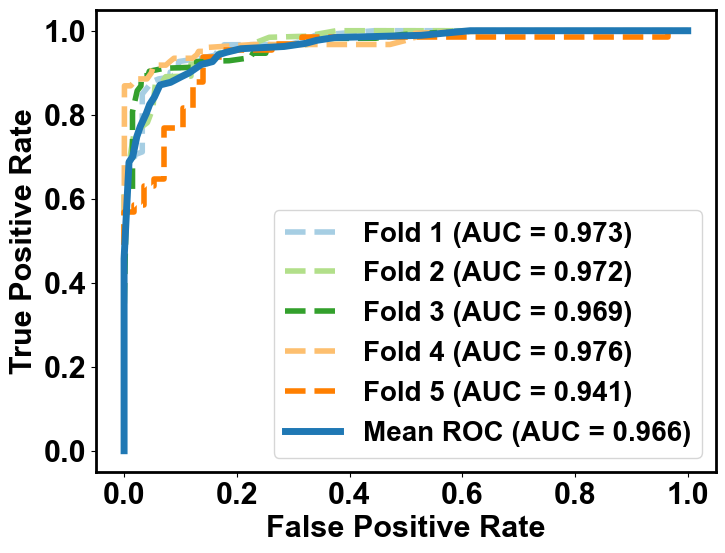

AUC for each fold: [np.float64(0.9725013220518246), np.float64(0.9719279661016949), np.float64(0.9690831556503199), np.float64(0.9756742464304602), np.float64(0.9411605937921729)]
Mean AUC: 0.9660694568052944
Image saved to E:/LLM+XWT/实验结果/Five_fold_esm_2_30_XWT/5_fold_roc_refined.png


In [18]:
#Drawing roc diagrams
# ---------------------------------------------------------
# 步骤 2: 绘图 (Plotting with custom styles)
# ---------------------------------------------------------
# 如果需要单独运行绘图，可以从这里开始，并加载上面的pkl文件
# with open(data_save_path, 'rb') as f:
#     data = pickle.load(f)
#     all_fpr = data['all_fpr']
#     all_tpr = data['all_tpr']
#     all_aucs = data['all_aucs']

# 指定配色
custom_colors = ["#A6CEE3", "#B2DF8A", "#33A02C", "#FDBF6F", "#FF7F00", "#FB9A99", "#1F78B4"]

plt.figure(figsize=(8, 6)) # 稍微调大一点画布以适应大字体

# 插值平滑处理 (保持原逻辑)
max_length = max(len(fpr) for fpr in all_fpr)
new_all_fpr = []
new_all_tpr = []
for fpr, tpr in zip(all_fpr, all_tpr):
    f = interp1d(np.linspace(0, 1, len(fpr)), fpr)
    t = interp1d(np.linspace(0, 1, len(tpr)), tpr)
    new_fpr = f(np.linspace(0, 1, max_length))
    new_tpr = t(np.linspace(0, 1, max_length))
    new_all_fpr.append(new_fpr)
    new_all_tpr.append(new_tpr)
all_fpr = new_all_fpr
all_tpr = new_all_tpr

# 绘制每一折
for i in range(len(all_fpr)):
    color_idx = i % len(custom_colors)
    plt.plot(all_fpr[i], all_tpr[i], 
             linestyle='--', 
             lw=4, # 线条加粗
             color=custom_colors[color_idx],
             label=f'Fold {i + 1} (AUC = {all_aucs[i]:.3f})')

# 绘制平均曲线
mean_fpr = np.mean(all_fpr, axis=0)
mean_tpr = np.mean(all_tpr, axis=0)
mean_color = custom_colors[-1] # 使用最后一个粉色或者您指定的颜色

plt.plot(mean_fpr, mean_tpr, 
         color=mean_color, 
         linestyle='-', 
         lw=5, # 平均线更粗一点
         label='Mean ROC (AUC = {:.3f})'.format(np.mean(all_aucs)))

# 设置图形属性
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

plt.xlabel('False Positive Rate', fontsize=22, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=22, fontweight='bold')

# 刻度字体设置
plt.xticks(fontsize=22, fontweight='bold')
plt.yticks(fontsize=22, fontweight='bold')

# 图例设置 (Arial, Bold, 20 - 稍微小一点以免遮挡，或者也用22)
# 注意：matplotlib图例自动继承全局字体，但为了保险起见可以强制指定
plt.legend(loc="lower right", fontsize=20, prop={'family': 'Arial', 'weight': 'bold', 'size': 20})

# 加粗边框 (可选，为了学术风更强)
ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

# 保存图片
image_save_path = os.path.join(save_dir, '5_fold_roc_refined.png')
plt.savefig(image_save_path, dpi=600, bbox_inches='tight')
plt.show()

print("AUC for each fold:", all_aucs)
print("Mean AUC:", np.mean(all_aucs))
print(f"Image saved to {image_save_path}")